SKIN CANCER MODEL: USING SVM , CNN AND RESNET_50

In [ ]:
# ===================================
# IMPORTING LIBRIES
# ===================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import classification_report, confusion_matrix


In [ ]:
# ===================================
# DEVICE CONFIGURATION
# ===================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [ ]:
# ===================================
# READING CSV FILE AND THE LENGTH OF CLASSES
# ===================================

import pandas as pd

metadata_path = r"C:\Users\DELL\Desktop\SKIN_CANCER\HAM10000_metadata.csv"
df = pd.read_csv(metadata_path)

print(df.head())
print("Total images:", len(df))
print("Classes:", df['dx'].unique())


     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear
Total images: 10015
Classes: <StringArray>
['bkl', 'nv', 'df', 'mel', 'vasc', 'bcc', 'akiec']
Length: 7, dtype: str


GRAYSCALE CONVERSION 

In [15]:
import os
import cv2
from tqdm import tqdm

input_dir1 = r"C:\Users\DELL\Desktop\SKIN_CANCER\HAM10000_images_part_1"
input_dir2 = r"C:\Users\DELL\Desktop\SKIN_CANCER\HAM10000_images_part_2"

output_dir1 = r"C:\Users\DELL\Desktop\SKIN_CANCER\HAM10000_gray\part_1"
output_dir2 = r"C:\Users\DELL\Desktop\SKIN_CANCER\HAM10000_gray\part_2"

os.makedirs(output_dir1, exist_ok=True)
os.makedirs(output_dir2, exist_ok=True)


def convert_to_grayscale(input_dir, output_dir):
    
    image_list = os.listdir(input_dir)
    
    print(f"\nConverting images from: {input_dir}")
    print("Total images:", len(image_list))
    
    for img_name in tqdm(image_list):
        
        img_path = os.path.join(input_dir, img_name)
        
        # Read image
        image = cv2.imread(img_path)
        
        if image is None:
            continue
        
        # Convert to grayscale
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        
        # Save image
        save_path = os.path.join(output_dir, img_name)
        cv2.imwrite(save_path, gray)
    
    print("Done ✅")

convert_to_grayscale(input_dir1, output_dir1)
convert_to_grayscale(input_dir2, output_dir2)



Converting images from: C:\Users\DELL\Desktop\SKIN_CANCER\HAM10000_images_part_1
Total images: 5000


100%|██████████| 5000/5000 [00:58<00:00, 84.85it/s]


Done ✅

Converting images from: C:\Users\DELL\Desktop\SKIN_CANCER\HAM10000_images_part_2
Total images: 5015


100%|██████████| 5015/5015 [01:00<00:00, 82.51it/s]

Done ✅


In [ ]:
# ===================================
# VERIFYING SHAPE
# ==================================

sample_img = cv2.imread(os.path.join(output_dir1, os.listdir(output_dir1)[0]), 0)
print("Shape:", sample_img.shape)

Shape: (450, 600)


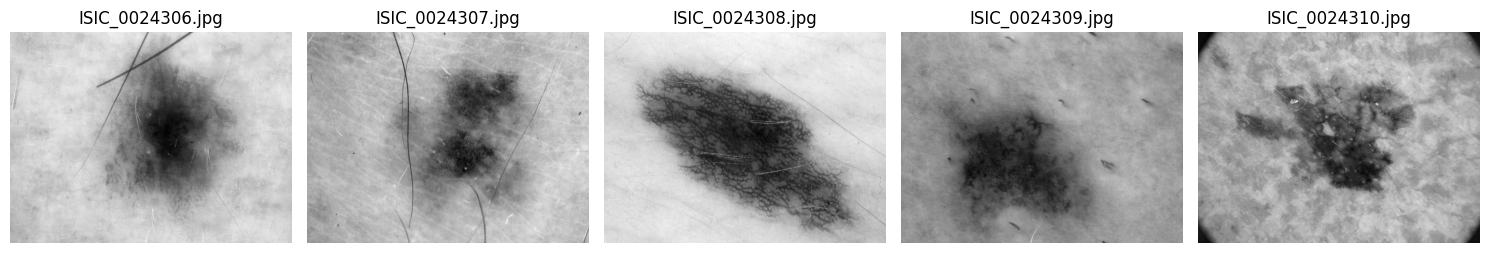

In [ ]:
# ===================================
# PRINT SOME GRAYSCALE IMAGE
# ==================================

import os
import cv2
import matplotlib.pyplot as plt

# Path to grayscale folder
gray_folder = r"C:\Users\DELL\Desktop\SKIN_CANCER\HAM10000_gray\part_1"

# Get first 5 images
image_list = os.listdir(gray_folder)[:5]

plt.figure(figsize=(15,5))

for i, img_name in enumerate(image_list):
    img_path = os.path.join(gray_folder, img_name)
    
    # Read as grayscale
    img = cv2.imread(img_path, 0)
    
    plt.subplot(1, 5, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(img_name)
    plt.axis("off")

plt.tight_layout()
plt.show()


HAIR REMOVAL USING BLACKHAT MORPHOLOGY

In [18]:
import os
import cv2
import numpy as np
from tqdm import tqdm


input_dir1 = r"C:\Users\DELL\Desktop\SKIN_CANCER\HAM10000_gray\part_1"
input_dir2 = r"C:\Users\DELL\Desktop\SKIN_CANCER\HAM10000_gray\part_2"

output_dir1 = r"C:\Users\DELL\Desktop\SKIN_CANCER\HAM10000_no_hair\part_1"
output_dir2 = r"C:\Users\DELL\Desktop\SKIN_CANCER\HAM10000_no_hair\part_2"

os.makedirs(output_dir1, exist_ok=True)
os.makedirs(output_dir2, exist_ok=True)


def remove_hair(input_dir, output_dir):
    
    image_list = os.listdir(input_dir)
    print(f"\nProcessing: {input_dir}")
    print("Total images:", len(image_list))
    
    for img_name in tqdm(image_list):
        
        img_path = os.path.join(input_dir, img_name)
        img = cv2.imread(img_path, 0)  # grayscale
        
        if img is None:
            continue
        
        # Step 1: Create blackhat filter to detect dark hairs
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (17, 17))
        blackhat = cv2.morphologyEx(img, cv2.MORPH_BLACKHAT, kernel)
        
        # Step 2: Threshold to create mask
        _, mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
        
        # Step 3: Inpaint (remove hairs)
        inpainted = cv2.inpaint(img, mask, 1, cv2.INPAINT_TELEA)
        
        # Save result
        save_path = os.path.join(output_dir, img_name)
        cv2.imwrite(save_path, inpainted)
    
    print("Hair removal done")


remove_hair(input_dir1, output_dir1)
remove_hair(input_dir2, output_dir2)



Processing: C:\Users\DELL\Desktop\SKIN_CANCER\HAM10000_gray\part_1
Total images: 5000


100%|██████████| 5000/5000 [02:38<00:00, 31.63it/s]


Hair removal done

Processing: C:\Users\DELL\Desktop\SKIN_CANCER\HAM10000_gray\part_2
Total images: 5015


100%|██████████| 5015/5015 [02:50<00:00, 29.45it/s]

Hair removal done


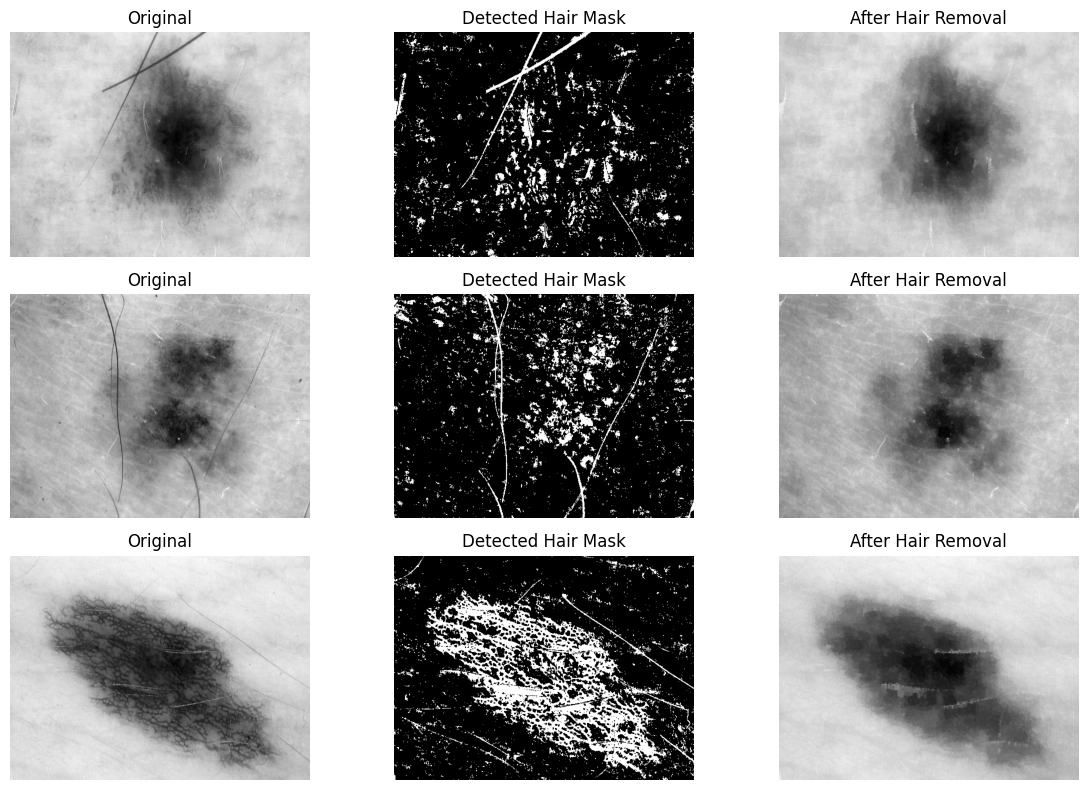

In [ ]:
# =====================================
# PRINT SOME IMAGE AFTER HAIR REMOVAL
# =====================================

import os
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Path settings
input_dir = r"C:\Users\DELL\Desktop\SKIN_CANCER\HAM10000_gray\part_1"
output_dir = r"C:\Users\DELL\Desktop\SKIN_CANCER\HAM10000_no_hair\part_1"

# Pick 3 random images
image_list = os.listdir(input_dir)[:3]

plt.figure(figsize=(12, 8))

for i, img_name in enumerate(image_list):
    
    before = cv2.imread(os.path.join(input_dir, img_name), 0)
    after = cv2.imread(os.path.join(output_dir, img_name), 0)
    
    # Recreate mask for visualization
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (17, 17))
    blackhat = cv2.morphologyEx(before, cv2.MORPH_BLACKHAT, kernel)
    _, mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)

    # Original
    plt.subplot(3, 3, i*3 + 1)
    plt.imshow(before, cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Hair Mask
    plt.subplot(3, 3, i*3 + 2)
    plt.imshow(mask, cmap='gray')
    plt.title("Detected Hair Mask")
    plt.axis("off")

    # After Removal
    plt.subplot(3, 3, i*3 + 3)
    plt.imshow(after, cmap='gray')
    plt.title("After Hair Removal")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
# =====================================
# MERGEING TWO (NO_HAIR) FILE 
# =====================================

import os
import shutil
from tqdm import tqdm

part1_dir = r"C:\Users\DELL\Desktop\SKIN_CANCER\HAM10000_no_hair\part_1"
part2_dir = r"C:\Users\DELL\Desktop\SKIN_CANCER\HAM10000_no_hair\part_2"

merged_dir = r"C:\Users\DELL\Desktop\SKIN_CANCER\HAM10000_no_hair_merged"

os.makedirs(merged_dir, exist_ok=True)


def merge_folders(source_dir, target_dir):
    
    image_list = os.listdir(source_dir)
    print(f"Merging from: {source_dir}")
    print("Total images:", len(image_list))
    
    for img_name in tqdm(image_list):
        src_path = os.path.join(source_dir, img_name)
        dst_path = os.path.join(target_dir, img_name)
        
        shutil.copy(src_path, dst_path)
    
    print("Done")


merge_folders(part1_dir, merged_dir)
merge_folders(part2_dir, merged_dir)

print("Total merged images:", len(os.listdir(merged_dir)))


Merging from: C:\Users\DELL\Desktop\SKIN_CANCER\HAM10000_no_hair\part_1
Total images: 5000


100%|██████████| 5000/5000 [01:16<00:00, 65.74it/s] 


Done
Merging from: C:\Users\DELL\Desktop\SKIN_CANCER\HAM10000_no_hair\part_2
Total images: 5015


100%|██████████| 5015/5015 [01:34<00:00, 53.31it/s]

Done
Total merged images: 10015


MULTICLASS SVM TRANING

In [3]:
import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm

from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score


In [4]:
metadata_path = r"C:\Users\DELL\Desktop\SKIN_CANCER\HAM10000_metadata.csv"
image_dir = r"C:\Users\DELL\Desktop\SKIN_CANCER\HAM10000_no_hair_merged"

df = pd.read_csv(metadata_path)

print("Total samples:", len(df))
print("Classes:", df["dx"].unique())

Total samples: 10015
Classes: <StringArray>
['bkl', 'nv', 'df', 'mel', 'vasc', 'bcc', 'akiec']
Length: 7, dtype: str


In [ ]:
# =====================================
# ENCODE LABELS
# =====================================

le = LabelEncoder()
df["label"] = le.fit_transform(df["dx"])

In [ ]:
# =====================================
# Extract HOG Features
# HOG = Histogram of Oriented Gradients
# It is a feature extraction technique used in classical machine learning to capture : The shape and edge structure of an image.
# =====================================

X = []
y = []

print("Extracting HOG features...")

for _, row in tqdm(df.iterrows(), total=len(df)):
    
    img_name = row["image_id"] + ".jpg"
    img_path = os.path.join(image_dir, img_name)
    
    if not os.path.exists(img_path):
        continue
    
    img = cv2.imread(img_path, 0)
    img = cv2.resize(img, (128, 128))
    
    features = hog(
        img,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        visualize=False
    )
    
    X.append(features)
    y.append(row["label"])

X = np.array(X)
y = np.array(y)

print("Feature shape:", X.shape)
 

Extracting HOG features...


100%|██████████| 10015/10015 [01:15<00:00, 132.73it/s]


Feature shape: (10015, 8100)


In [ ]:
# =====================================
# TRANING : 80%
# TESTING : 20%
# =====================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (8012, 8100)
Test size: (2003, 8100)


In [ ]:
# =====================================
# MODEL TRANING
# =====================================

print("Training SVM...")

svm_model = SVC(kernel="linear")
svm_model.fit(X_train, y_train)

print("Training complete")

Training SVM...
Training complete


In [ ]:
# =====================================
# PRINTING  : ACCURACY , MACRO AVG AND WT. AVG
# =====================================

y_pred = svm_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.5631552670993509

Classification Report:

              precision    recall  f1-score   support

           0       0.18      0.20      0.19        65
           1       0.16      0.19      0.17       103
           2       0.18      0.23      0.20       220
           3       0.00      0.00      0.00        23
           4       0.24      0.25      0.24       223
           5       0.78      0.74      0.76      1341
           6       0.00      0.00      0.00        28

    accuracy                           0.56      2003
   macro avg       0.22      0.23      0.22      2003
weighted avg       0.58      0.56      0.57      2003



MULTICLASS CNN

In [17]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [ ]:
# =====================================
# TRANING : 80%
# TESTING : 20%
# =====================================

metadata_path = r"C:\Users\DELL\Desktop\SKIN_CANCER\HAM10000_metadata.csv"
image_dir = r"C:\Users\DELL\Desktop\SKIN_CANCER\HAM10000_no_hair_merged"

df = pd.read_csv(metadata_path)

le = LabelEncoder()
df["label"] = le.fit_transform(df["dx"])

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

print("Train size:", len(train_df))
print("Val size:", len(val_df))


Train size: 8012
Val size: 2003


In [ ]:
# =====================================
# LOADING AND PREPROCESSING IMAGE
# =====================================

class HAMDataset(Dataset):
    def __init__(self, dataframe, image_dir):
        self.df = dataframe
        self.image_dir = image_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.image_dir, row["image_id"] + ".jpg")

        image = cv2.imread(img_path, 0)  # grayscale
        image = cv2.resize(image, (128, 128))

        image = image / 255.0
        image = np.expand_dims(image, axis=0)  # add channel dimension

        image = torch.tensor(image, dtype=torch.float32)
        label = torch.tensor(row["label"], dtype=torch.long)

        return image, label


In [ ]:
train_dataset = HAMDataset(train_df, image_dir)
val_dataset = HAMDataset(val_df, image_dir)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)


In [ ]:
# =====================================
# CNN TRANING 
# =====================================

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x


THEIR ARE THREE CONVOLUTIONAL LAYER :-
Conv2d(1 → 32)
Conv2d(32 → 64)
Conv2d(64 → 128)

I/P in CNN is  : [1,128,128]

First convolutional layer : [32,128,128] ----------------->>>> [feature,height,width]

                For first convolutional layer we are using [32 : Filter] scaning (Edges, Corners, Simple textures)

                Then using max_pooling reducedes the size by half : [32,64,64]


Second convolutional layer : [64,64,64] ----------------->>>> [feature,height,width]

                For second convolutional layer we are using [64 : Filter] scaning (More complex shapes, Pattern combinations, Lesion structure details)

                Then using max_pooling reducedes the size by half : [64,32,32]


Third convolutional layer : [128,32,32] ----------------->>>> [feature,height,width]

                For third convolutional layer we are using [128 : Filter] scaning (High-level lesion patterns, Cancer-specific structures, Texture irregularities)
                
                Then using max_pooling reducedes the size by half : [128,16,16]


PATH : Edge detectors → shape detectors → lesion detectors

Layer	Output Shape
Input	(1, 128, 128)

Conv1	(32, 128, 128)

Pool1	(32, 64, 64)

Conv2	(64, 64, 64)

Pool2	(64, 32, 32)

Conv3	(128, 32, 32)

Pool3	(128, 16, 16)

In [23]:
num_classes = len(le.classes_)
model = SimpleCNN(num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [24]:
epochs = 20

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {running_loss/len(train_loader):.4f}")


Epoch [1/20] Loss: 1.0686
Epoch [2/20] Loss: 0.9959
Epoch [3/20] Loss: 0.9415
Epoch [4/20] Loss: 0.9000
Epoch [5/20] Loss: 0.8710
Epoch [6/20] Loss: 0.8278
Epoch [7/20] Loss: 0.7993
Epoch [8/20] Loss: 0.7636
Epoch [9/20] Loss: 0.7196
Epoch [10/20] Loss: 0.6782
Epoch [11/20] Loss: 0.6202
Epoch [12/20] Loss: 0.5802
Epoch [13/20] Loss: 0.5286
Epoch [14/20] Loss: 0.4703
Epoch [15/20] Loss: 0.4153
Epoch [16/20] Loss: 0.3764
Epoch [17/20] Loss: 0.3355
Epoch [18/20] Loss: 0.2938
Epoch [19/20] Loss: 0.2520
Epoch [20/20] Loss: 0.2400


In [25]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Validation Accuracy:", 100 * correct / total)


Validation Accuracy: 69.29605591612581


BINARY SVM

In [ ]:
import pandas as pd

metadata_path = r"C:\Users\DELL\Desktop\SKIN_CANCER\HAM10000_metadata.csv"
df = pd.read_csv(metadata_path)

# Define malignant classes
malignant_classes = ['mel', 'bcc']

# Create binary label
df['binary_label'] = df['dx'].apply(lambda x: 1 if x in malignant_classes else 0)

print(df['binary_label'].value_counts())


# 0 → Benign
#1 → Malignant


binary_label
0    8388
1    1627
Name: count, dtype: int64


In [27]:
import os
import cv2
import numpy as np
from tqdm import tqdm
from skimage.feature import hog

image_dir = r"C:\Users\DELL\Desktop\SKIN_CANCER\HAM10000_no_hair_merged"

X = []
y = []

print("Extracting HOG features...")

for _, row in tqdm(df.iterrows(), total=len(df)):
    
    img_name = row["image_id"] + ".jpg"
    img_path = os.path.join(image_dir, img_name)

    if not os.path.exists(img_path):
        continue

    img = cv2.imread(img_path, 0)
    img = cv2.resize(img, (128, 128))

    features = hog(
        img,
        orientations=9,
        pixels_per_cell=(8,8),
        cells_per_block=(2,2),
        visualize=False
    )

    X.append(features)
    y.append(row["binary_label"])

X = np.array(X)
y = np.array(y)

print("Feature shape:", X.shape)


Extracting HOG features...


100%|██████████| 10015/10015 [00:50<00:00, 198.48it/s]


Feature shape: (10015, 8100)


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [30]:
from sklearn.svm import SVC

print("Training Binary SVM...")

svm_model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    class_weight='balanced',
    verbose=True
)

svm_model.fit(X_train, y_train)

print("Training complete ✅")


Training Binary SVM...
[LibSVM]Training complete ✅


In [31]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

y_pred = svm_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8312531203195207

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.98      0.91      1678
           1       0.41      0.09      0.14       325

    accuracy                           0.83      2003
   macro avg       0.63      0.53      0.52      2003
weighted avg       0.77      0.83      0.78      2003

Confusion Matrix:
 [[1637   41]
 [ 297   28]]


BINARY CNN

In [32]:
import pandas as pd

metadata_path = r"C:\Users\DELL\Desktop\SKIN_CANCER\HAM10000_metadata.csv"
image_dir = r"C:\Users\DELL\Desktop\SKIN_CANCER\HAM10000_no_hair_merged"

df = pd.read_csv(metadata_path)

malignant_classes = ['mel', 'bcc']

df['binary_label'] = df['dx'].apply(lambda x: 1 if x in malignant_classes else 0)

print(df['binary_label'].value_counts())


binary_label
0    8388
1    1627
Name: count, dtype: int64


In [33]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['binary_label'],
    random_state=42
)

print("Train:", len(train_df))
print("Val:", len(val_df))


Train: 8012
Val: 2003


In [34]:
import os
import cv2
import torch
import numpy as np
from torch.utils.data import Dataset

class BinaryHAMDataset(Dataset):
    def __init__(self, dataframe, image_dir):
        self.df = dataframe
        self.image_dir = image_dir

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.image_dir, row["image_id"] + ".jpg")

        image = cv2.imread(img_path, 0)  # grayscale
        image = cv2.resize(image, (128, 128))

        image = image / 255.0
        image = np.expand_dims(image, axis=0)

        image = torch.tensor(image, dtype=torch.float32)
        label = torch.tensor(row["binary_label"], dtype=torch.float32)

        return image, label


In [35]:
from torch.utils.data import DataLoader

train_dataset = BinaryHAMDataset(train_df, image_dir)
val_dataset = BinaryHAMDataset(val_df, image_dir)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)


In [36]:
import torch.nn as nn

class BinaryCNN(nn.Module):
    def __init__(self):
        super(BinaryCNN, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 1)   # 1 output neuron
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x


In [37]:
import torch
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = BinaryCNN().to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [38]:
epochs = 20

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {running_loss/len(train_loader):.4f}")


Epoch [1/20] Loss: 0.4519
Epoch [2/20] Loss: 0.4340
Epoch [3/20] Loss: 0.4182
Epoch [4/20] Loss: 0.4096
Epoch [5/20] Loss: 0.3990
Epoch [6/20] Loss: 0.3880
Epoch [7/20] Loss: 0.3793
Epoch [8/20] Loss: 0.3716
Epoch [9/20] Loss: 0.3597
Epoch [10/20] Loss: 0.3450
Epoch [11/20] Loss: 0.3294
Epoch [12/20] Loss: 0.3211
Epoch [13/20] Loss: 0.2992
Epoch [14/20] Loss: 0.2840
Epoch [15/20] Loss: 0.2604
Epoch [16/20] Loss: 0.2398
Epoch [17/20] Loss: 0.2180
Epoch [18/20] Loss: 0.1999
Epoch [19/20] Loss: 0.1799
Epoch [20/20] Loss: 0.1544


In [39]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)

        outputs = model(images)
        predictions = torch.sigmoid(outputs)
        predicted = (predictions > 0.5).float()

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Validation Accuracy:", 100 * correct / total)


Validation Accuracy: 82.42636045931103


MULTICLASS RASNET 50

In [48]:
import pandas as pd

metadata_path = r"C:\Users\DELL\Desktop\SKIN_CANCER\HAM10000_metadata.csv"
image_dir = r"C:\Users\DELL\Desktop\SKIN_CANCER\HAM10000_images_merged"  # Use RGB images

df = pd.read_csv(metadata_path)

print("Classes:", df["dx"].unique())


Classes: <StringArray>
['bkl', 'nv', 'df', 'mel', 'vasc', 'bcc', 'akiec']
Length: 7, dtype: str


In [49]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["label"] = le.fit_transform(df["dx"])

num_classes = len(le.classes_)
print("Number of classes:", num_classes)


Number of classes: 7


In [58]:
import shutil
import os

part1 = r"C:\Users\DELL\Desktop\SKIN_CANCER\HAM10000_images_part_1"
part2 = r"C:\Users\DELL\Desktop\SKIN_CANCER\HAM10000_images_part_2"
merged = r"C:\Users\DELL\Desktop\SKIN_CANCER\HAM10000_images_merged"

os.makedirs(merged, exist_ok=True)

for folder in [part1, part2]:
    for img in os.listdir(folder):
        shutil.copy(os.path.join(folder, img), merged)


In [60]:
import os
import cv2
import numpy as np
from tqdm import tqdm

input_dir = r"C:\Users\DELL\Desktop\SKIN_CANCER\HAM10000_images_merged"
output_dir = r"C:\Users\DELL\Desktop\SKIN_CANCER\HAM10000_rgb_no_hair"

os.makedirs(output_dir, exist_ok=True)

In [62]:
def remove_hair_rgb(input_dir, output_dir):
    
    image_list = os.listdir(input_dir)
    print("Total images:", len(image_list))
    
    for img_name in tqdm(image_list):
        
        img_path = os.path.join(input_dir, img_name)
        image = cv2.imread(img_path)

        if image is None:
            continue

        # Convert to grayscale for hair detection
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        # Blackhat to detect dark hairs
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (17,17))
        blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)

        # Threshold to create mask
        _, mask = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)

        # Inpaint on original RGB image
        inpainted = cv2.inpaint(image, mask, 1, cv2.INPAINT_TELEA)

        # Save cleaned RGB image
        save_path = os.path.join(output_dir, img_name)
        cv2.imwrite(save_path, inpainted)

    print("Hair removal completed")


In [63]:
remove_hair_rgb(input_dir, output_dir)

Total images: 10015


100%|██████████| 10015/10015 [09:16<00:00, 18.00it/s]

Hair removal completed


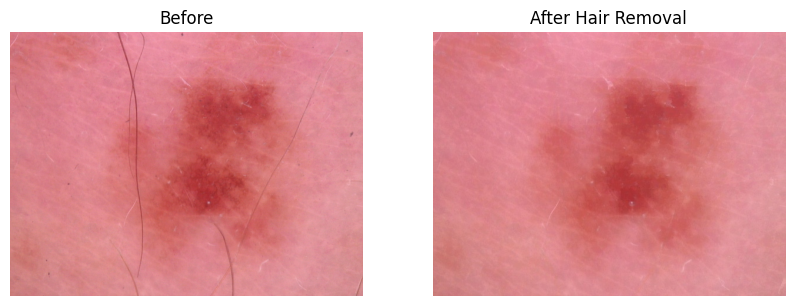

In [67]:
import matplotlib.pyplot as plt

sample = os.listdir(input_dir)[1]

before = cv2.imread(os.path.join(input_dir, sample))
before = cv2.cvtColor(before, cv2.COLOR_BGR2RGB)

after = cv2.imread(os.path.join(output_dir, sample))
after = cv2.cvtColor(after, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(before)
plt.title("Before")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(after)
plt.title("After Hair Removal")
plt.axis("off")

plt.show()


In [68]:
import os
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import cv2

In [69]:
metadata_path = r"C:\Users\DELL\Desktop\SKIN_CANCER\HAM10000_metadata.csv"
image_dir = r"C:\Users\DELL\Desktop\SKIN_CANCER\HAM10000_rgb_no_hair"

df = pd.read_csv(metadata_path)

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["label"] = le.fit_transform(df["dx"])

num_classes = len(le.classes_)
print("Classes:", le.classes_)


Classes: ['akiec' 'bcc' 'bkl' 'df' 'mel' 'nv' 'vasc']


In [70]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

In [71]:
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])


In [72]:
class HAMDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.df = dataframe
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.image_dir, row["image_id"] + ".jpg")

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(row["label"], dtype=torch.long)

        return image, label


In [73]:
train_dataset = HAMDataset(train_df, image_dir, train_transform)
val_dataset = HAMDataset(val_df, image_dir, val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)


In [74]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = models.resnet50(pretrained=True)

# Freeze backbone first
for param in model.parameters():
    param.requires_grad = False

# Replace final layer
model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)


Using device: cpu


c:\Users\DELL\anaconda3\envs\skin_cancer_env\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\DELL\anaconda3\envs\skin_cancer_env\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [75]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)


In [76]:
epochs = 20

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {running_loss/len(train_loader):.4f}")


Epoch [1/20] Loss: 0.8922
Epoch [2/20] Loss: 0.7353
Epoch [3/20] Loss: 0.7170
Epoch [4/20] Loss: 0.6935
Epoch [5/20] Loss: 0.6781
Epoch [6/20] Loss: 0.6795
Epoch [7/20] Loss: 0.6581
Epoch [8/20] Loss: 0.6636
Epoch [9/20] Loss: 0.6625
Epoch [10/20] Loss: 0.6599
Epoch [11/20] Loss: 0.6492
Epoch [12/20] Loss: 0.6527
Epoch [13/20] Loss: 0.6333
Epoch [14/20] Loss: 0.6579
Epoch [15/20] Loss: 0.6485
Epoch [16/20] Loss: 0.6390
Epoch [17/20] Loss: 0.6425
Epoch [18/20] Loss: 0.6196
Epoch [19/20] Loss: 0.6091
Epoch [20/20] Loss: 0.6337


In [77]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Validation Accuracy:", 100 * correct / total)


Validation Accuracy: 78.0329505741388


BINARY RASNET 50

In [78]:
import pandas as pd

metadata_path = r"C:\Users\DELL\Desktop\SKIN_CANCER\HAM10000_metadata.csv"
image_dir = r"C:\Users\DELL\Desktop\SKIN_CANCER\HAM10000_rgb_no_hair"  # if RGB version exists

df = pd.read_csv(metadata_path)

malignant_classes = ['mel', 'bcc']
df['binary_label'] = df['dx'].apply(lambda x: 1 if x in malignant_classes else 0)


In [79]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['binary_label'],
    random_state=42
)


In [80]:
import os
import cv2
import torch
import numpy as np
from torch.utils.data import Dataset
from torchvision import transforms

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

class HAMBinaryRGB(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.df = dataframe
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.image_dir, row["image_id"] + ".jpg")

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(row["binary_label"], dtype=torch.float32)

        return image, label


In [81]:
from torch.utils.data import DataLoader

train_dataset = HAMBinaryRGB(train_df, image_dir, transform)
val_dataset = HAMBinaryRGB(val_df, image_dir, transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)


In [82]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(pretrained=True)

# Freeze backbone
for param in model.parameters():
    param.requires_grad = False

# Replace final layer for binary classification
model.fc = nn.Linear(model.fc.in_features, 1)

model = model.to(device)


c:\Users\DELL\anaconda3\envs\skin_cancer_env\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\DELL\anaconda3\envs\skin_cancer_env\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [83]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)


In [84]:
epochs = 20

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {running_loss/len(train_loader):.4f}")


Epoch [1/20] Loss: 0.3811
Epoch [2/20] Loss: 0.3417
Epoch [3/20] Loss: 0.3352
Epoch [4/20] Loss: 0.3252
Epoch [5/20] Loss: 0.3222
Epoch [6/20] Loss: 0.3236
Epoch [7/20] Loss: 0.3205
Epoch [8/20] Loss: 0.3153
Epoch [9/20] Loss: 0.3185
Epoch [10/20] Loss: 0.3270
Epoch [11/20] Loss: 0.3175
Epoch [12/20] Loss: 0.3234
Epoch [13/20] Loss: 0.3108
Epoch [14/20] Loss: 0.3102
Epoch [15/20] Loss: 0.3098
Epoch [16/20] Loss: 0.3063
Epoch [17/20] Loss: 0.3060
Epoch [18/20] Loss: 0.3062
Epoch [19/20] Loss: 0.3103
Epoch [20/20] Loss: 0.3076


In [85]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)

        outputs = model(images)
        preds = torch.sigmoid(outputs)
        predicted = (preds > 0.5).float()

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Validation Accuracy:", 100 * correct / total)
        

Validation Accuracy: 84.47329006490264
